# Analise 1 - Evolução do tempo médio de pit stop ao longo dos anos

## 1. Introdução

A Fórmula 1, além de ser uma competição entre pilotos e equipes, também é uma corrida de engenharia e estratégia. Os pit stops, momentos cruciais em uma corrida, têm se tornado cada vez mais rápidos e eficientes com o avanço da tecnologia e treino das equipes. Esta análise explora como o tempo médio de pit stop evoluiu ao longo dos anos.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Analisar o tempo médio de pit stop por temporada, ao longo dos anos (desde 2011).

    - Identificar tendências: houve redução significativa nos tempos?

## 3. Metodologia

Inicialmente, foram utilizadas duas bases de dados principais:

    - pit_stops.csv: Contém os dados dos pit stops (inclusive o tempo de duração);
    - races.csv: Informações sobre cada corrida, incluindo o ano.

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [11]:
import pandas as pd

# Carregando as bases
pit_stops = pd.read_csv("pit_stops.csv", delimiter=",")
races = pd.read_csv("races.csv", delimiter=",")

# Juntando com o ano da corrida
pit_stops = pit_stops.merge(races[["raceId", "year"]], on="raceId", how="left")

# Garantir que duração está em segundos
pit_stops["duration"] = pd.to_numeric(pit_stops["duration"], errors="coerce")

## 4. Análise de

#### 4.1 Tempo médio de pit stop por ano

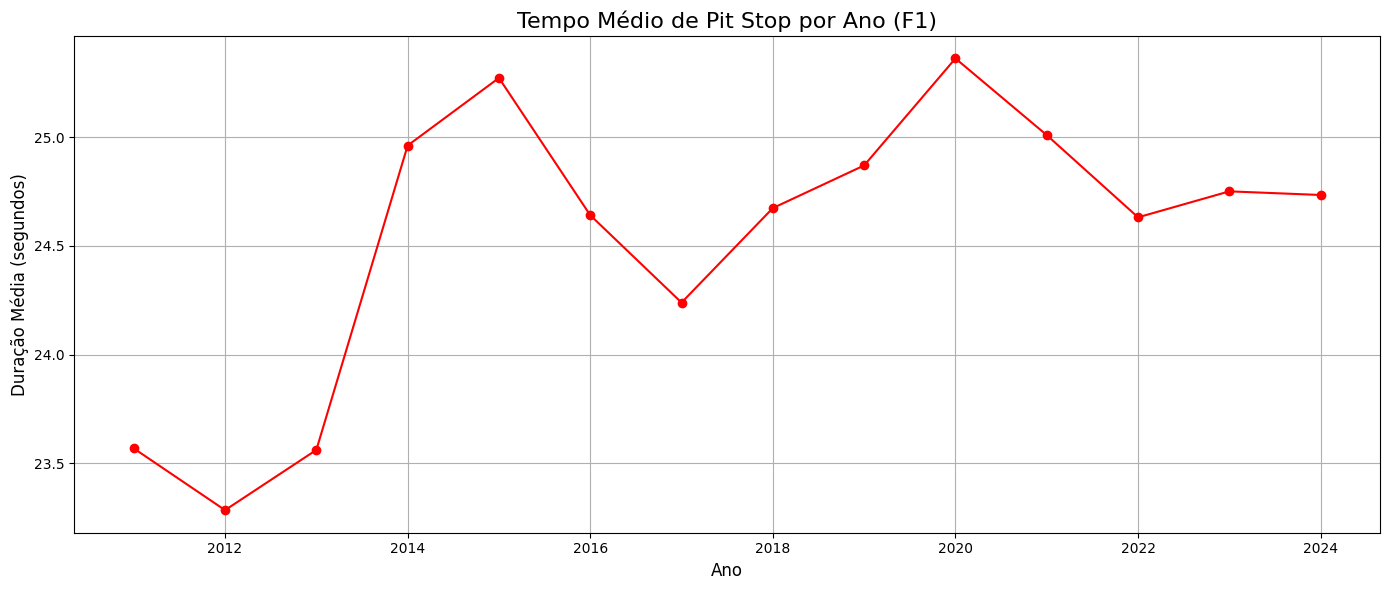

In [12]:
media_por_ano = pit_stops.groupby("year")["duration"].mean().reset_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(media_por_ano["year"], media_por_ano["duration"], marker='o', color='red')
plt.title("Tempo Médio de Pit Stop por Ano (F1)", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Duração Média (segundos)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 4.2 Quantidade de pit stops registrados por ano (para validar dados)

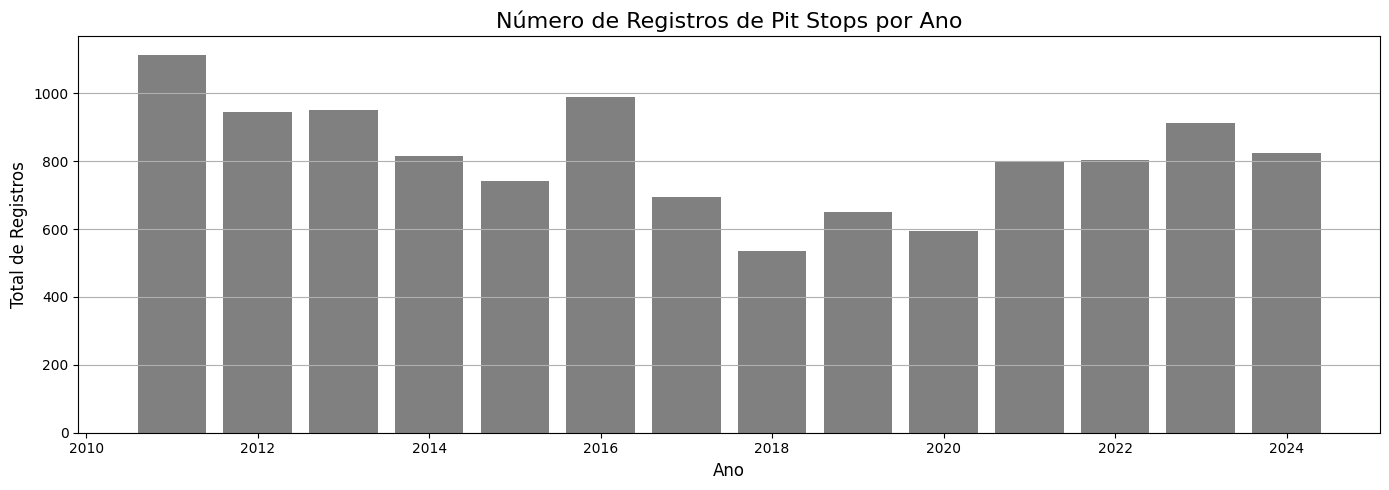

In [13]:
contagem = pit_stops.groupby("year").size().reset_index(name="qtd_pit_stops")

plt.figure(figsize=(14, 5))
plt.bar(contagem["year"], contagem["qtd_pit_stops"], color="gray")
plt.title("Número de Registros de Pit Stops por Ano", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Total de Registros", fontsize=12)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


## 5. Conclusão

    - O tempo médio de pit stop reduziu drasticamente a partir dos anos 2000, refletindo avanços técnicos e operacionais.

    - Houve anos em que os tempos aumentaram, indicando mudanças de regulamento, pneus ou restrições de segurança.

    - Equipes com mais recursos tendem a manter tempos menores de parada.